In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [49]:
dfrsd = pd.read_csv('real-state-data.csv').copy()
dfrsd.head()

,Unnamed: 0,customerid,full_name,age,entity,sex,country,state,purpose,deal_satisfaction,mortgage,source,id,building,date_sale,type,property#,area,price,status
0,0,C0001,Kamd Co,62.0,0.0,Unknown,1.0,1.0,0.0,5.0,0.0,Agency,1005,1,2004-03-01,Office,5,410.71,"$117,564.07",1
1,1,C0002,Jack Anderson,78.0,1.0,M,1.0,1.0,0.0,5.0,1.0,Website,1002,1,2004-03-01,Office,2,1238.58,"$410,932.67",1
2,2,C0003,Avah Huang,77.0,1.0,F,1.0,1.0,1.0,5.0,0.0,Website,1044,1,2004-06-01,Apartment,44,827.87,"$229,464.71",1
3,3,C0004,Nora Lynch,77.0,1.0,F,1.0,1.0,1.0,5.0,0.0,Website,1043,1,2004-06-01,Apartment,43,1160.36,"$377,313.56",1
4,4,C0005,Rodolfo Gibson,89.0,1.0,M,1.0,0.0,1.0,2.0,1.0,Website,1033,1,2004-08-01,Apartment,33,1434.09,"$412,856.56",1


In [3]:
avg_country = pd.read_csv('avg_country.csv').copy()
avg_country

,country,avg_price,avg_area,avg_deal_satisfaction
0,0,262927.788889,890.748333,3.777778
1,1,270096.266554,900.794463,3.581921


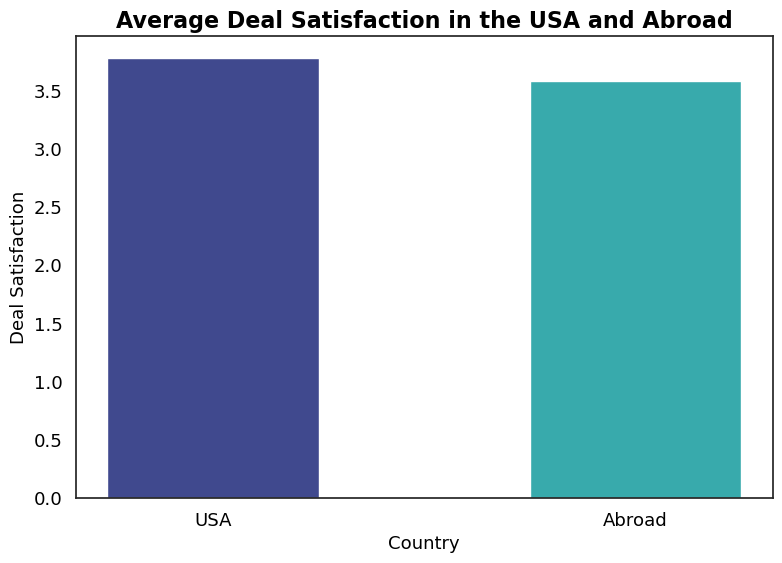

<Figure size 640x480 with 0 Axes>

In [4]:
avg_country['country'] = avg_country['country'].map({0: 'USA',1:'Abroad'})

sns.set_style('white')
plt.figure(figsize = (9, 6))
plt.bar(avg_country['country'],
         avg_country['avg_deal_satisfaction'],
         width = 0.5,
         color = sns.color_palette("mako", n_colors = len(avg_country)))

plt.xticks(fontsize = 13, color = 'black')
plt.yticks(fontsize = 13, color = 'black')

plt.title('Average Deal Satisfaction in the USA and Abroad', 
          fontsize = 16, 
          fontweight = 'bold', 
          color = 'black')
plt.xlabel('Country', 
           fontsize = 13, 
           color = 'black')
plt.ylabel('Deal Satisfaction', 
           fontsize = 13,
           color = 'black')
plt.style.use('classic')
plt.show()
plt.savefig('Avg_Deal_Satisfaction_Country.jpg')


In [5]:
dfrsd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         267 non-null    int64  
 1   customerid         195 non-null    object 
 2   full_name          195 non-null    object 
 3   age                195 non-null    float64
 4   entity             195 non-null    float64
 5   sex                195 non-null    object 
 6   country            195 non-null    float64
 7   state              195 non-null    float64
 8   purpose            195 non-null    float64
 9   deal_satisfaction  195 non-null    float64
 10  mortgage           195 non-null    float64
 11  source             195 non-null    object 
 12  id                 267 non-null    int64  
 13  building           267 non-null    int64  
 14  date_sale          195 non-null    object 
 15  type               267 non-null    object 
 16  property#          267 non

In [6]:
dfrsd['date_sale'] = pd.to_datetime(dfrsd['date_sale'])

In [7]:
dfrsd['date_sale'].unique()

<DatetimeArray>
['2004-03-01 00:00:00', '2004-06-01 00:00:00', '2004-08-01 00:00:00',
 '2004-10-01 00:00:00', '2004-11-01 00:00:00', '2005-01-01 00:00:00',
 '2005-02-01 00:00:00', '2005-03-01 00:00:00', '2005-04-01 00:00:00',
 '2005-06-01 00:00:00', '2005-08-01 00:00:00', '2005-09-01 00:00:00',
 '2005-10-01 00:00:00', '2005-11-01 00:00:00', '2005-12-01 00:00:00',
 '2006-02-01 00:00:00', '2006-04-01 00:00:00', '2006-06-01 00:00:00',
 '2006-07-01 00:00:00', '2006-08-01 00:00:00', '2006-09-01 00:00:00',
 '2006-10-01 00:00:00', '2006-11-01 00:00:00', '2007-10-01 00:00:00',
 '2007-08-01 00:00:00', '2006-12-01 00:00:00', '2007-01-01 00:00:00',
 '2007-02-01 00:00:00', '2007-11-01 00:00:00', '2007-03-01 00:00:00',
 '2007-04-01 00:00:00', '2007-12-01 00:00:00', '2008-05-01 00:00:00',
 '2010-05-01 00:00:00', '2007-05-01 00:00:00', '2007-06-01 00:00:00',
 '2007-07-01 00:00:00', '2007-09-01 00:00:00', '2006-03-01 00:00:00',
 '2008-12-01 00:00:00', '2006-05-01 00:00:00', '2008-01-01 00:00:00',
 '20

In [8]:
dfrsd['year'] = dfrsd['date_sale'].dt.year
dfrsd['month'] = dfrsd['date_sale'].dt.month
dfrsd['price'] = dfrsd['price'].str.strip()
dfrsd['price'] = dfrsd['price'].str.replace('$','')
dfrsd['price'] = dfrsd['price'].str.replace(',','')
dfrsd['price'] = dfrsd['price'].astype('Float64')

In [9]:
dfrsd['net_price'] = np.where(dfrsd['status'] == 1, dfrsd['price'],0)

In [10]:
dfrsd['net_price']

0      117564.07
1      410932.67
2      229464.71
3      377313.56
4      412856.56
         ...    
262         0.00
263         0.00
264         0.00
265         0.00
266         0.00
Name: net_price, Length: 267, dtype: float64

In [11]:
net = dfrsd.groupby(['year','month'])['net_price'].sum()
net

year    month
2004.0  3.0       697655.03
        6.0       606778.27
        8.0       620437.99
        10.0     1214785.83
        11.0     1257352.68
2005.0  1.0       215410.28
        2.0       432679.91
        3.0      1342646.64
        4.0       261579.89
        6.0       650580.08
        7.0      2191205.26
        8.0       475600.88
        9.0       222947.21
        10.0      246331.90
        11.0      246172.68
        12.0      930077.68
2006.0  2.0       224076.84
        3.0      1034735.22
        4.0       234172.39
        5.0       222867.42
        6.0      1003813.71
        7.0       447189.24
        8.0      1546259.94
        9.0      2107606.09
        10.0     1650060.87
        11.0     1579683.00
        12.0      855535.86
2007.0  1.0      1017797.02
        2.0      1747383.36
        3.0      3515639.15
        4.0      3103672.73
        5.0      1904934.34
        6.0      1721339.18
        7.0      1454980.23
        8.0      2243552.63
      

In [12]:
revenue = pd.DataFrame({'net_revenue': net}).fillna(0).reset_index()
revenue

,year,month,net_revenue
0,2004.0,3.0,697655.03
1,2004.0,6.0,606778.27
2,2004.0,8.0,620437.99
3,2004.0,10.0,1214785.83
4,2004.0,11.0,1257352.68
5,2005.0,1.0,215410.28
6,2005.0,2.0,432679.91
7,2005.0,3.0,1342646.64
8,2005.0,4.0,261579.89
9,2005.0,6.0,650580.08


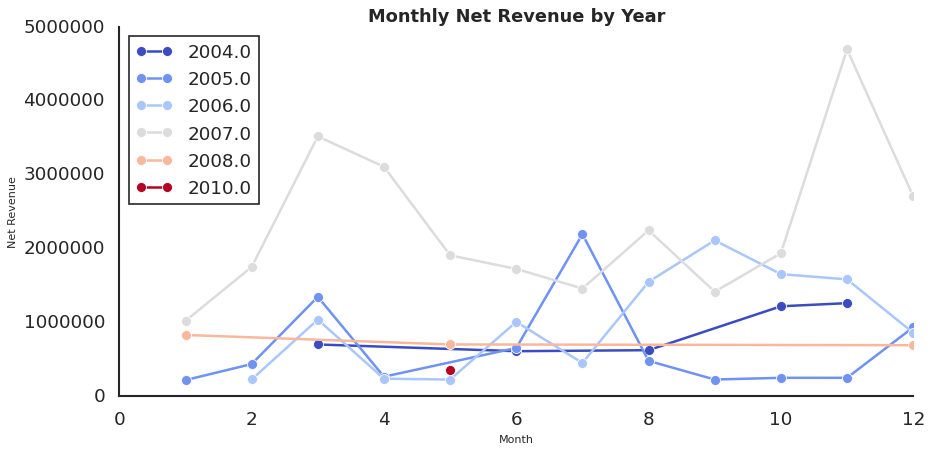

<Figure size 640x480 with 0 Axes>

In [13]:
sns.set_style('white')
sns.set_context('talk')
palette = sns.color_palette('coolwarm', as_cmap = True)

plt.figure(figsize = (12, 6))
sns.lineplot(data = revenue,
             x = 'month',
             y = 'net_revenue',
             hue = 'year',
             marker = 'o',
             palette = palette)
plt.title('Monthly Net Revenue by Year', fontsize = 16, fontweight = 'bold')
plt.xlabel('Month', fontsize = 10)
plt.ylabel('Net Revenue', fontsize = 10)
plt.legend(loc = 'upper left')

sns.despine()
plt.tight_layout()
plt.show()
plt.savefig('Monthly Net Revenue by Year')


In [14]:
dfrsd1 = dfrsd
dfrsd1['state'] = np.where(dfrsd1['state'] == 1, 'California', 'Other')
dfrsd1


,Unnamed: 0,customerid,full_name,age,entity,sex,country,state,purpose,deal_satisfaction,...,building,date_sale,type,property#,area,price,status,year,month,net_price
0,0,C0001,Kamd Co,62.0,0.0,Unknown,1.0,California,0.0,5.0,...,1,2004-03-01,Office,5,410.71,117564.07,1,2004.0,3.0,117564.07
1,1,C0002,Jack Anderson,78.0,1.0,M,1.0,California,0.0,5.0,...,1,2004-03-01,Office,2,1238.58,410932.67,1,2004.0,3.0,410932.67
2,2,C0003,Avah Huang,77.0,1.0,F,1.0,California,1.0,5.0,...,1,2004-06-01,Apartment,44,827.87,229464.71,1,2004.0,6.0,229464.71
3,3,C0004,Nora Lynch,77.0,1.0,F,1.0,California,1.0,5.0,...,1,2004-06-01,Apartment,43,1160.36,377313.56,1,2004.0,6.0,377313.56
4,4,C0005,Rodolfo Gibson,89.0,1.0,M,1.0,Other,1.0,2.0,...,1,2004-08-01,Apartment,33,1434.09,412856.56,1,2004.0,8.0,412856.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,262,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,...,5,NaT,Apartment,44,1238.58,322610.74,0,NaN,NaN,0.00
263,263,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,...,5,NaT,Apartment,47,794.52,279191.26,0,NaN,NaN,0.00
264,264,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,...,5,NaT,Apartment,48,1013.27,287996.53,0,NaN,NaN,0.00
265,265,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,...,5,NaT,Apartment,50,1074.71,365868.78,0,NaN,NaN,0.00


In [15]:
sold_df = dfrsd1[dfrsd1['status'] == 1]
sold_df

,Unnamed: 0,customerid,full_name,age,entity,sex,country,state,purpose,deal_satisfaction,...,building,date_sale,type,property#,area,price,status,year,month,net_price
0,0,C0001,Kamd Co,62.0,0.0,Unknown,1.0,California,0.0,5.0,...,1,2004-03-01,Office,5,410.71,117564.07,1,2004.0,3.0,117564.07
1,1,C0002,Jack Anderson,78.0,1.0,M,1.0,California,0.0,5.0,...,1,2004-03-01,Office,2,1238.58,410932.67,1,2004.0,3.0,410932.67
2,2,C0003,Avah Huang,77.0,1.0,F,1.0,California,1.0,5.0,...,1,2004-06-01,Apartment,44,827.87,229464.71,1,2004.0,6.0,229464.71
3,3,C0004,Nora Lynch,77.0,1.0,F,1.0,California,1.0,5.0,...,1,2004-06-01,Apartment,43,1160.36,377313.56,1,2004.0,6.0,377313.56
4,4,C0005,Rodolfo Gibson,89.0,1.0,M,1.0,Other,1.0,2.0,...,1,2004-08-01,Apartment,33,1434.09,412856.56,1,2004.0,8.0,412856.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,190,C0174,Marleez Co,62.0,0.0,Unknown,1.0,California,0.0,5.0,...,1,2005-07-01,Apartment,28,1160.36,331154.88,1,2005.0,7.0,331154.88
191,191,C0174,Marleez Co,62.0,0.0,Unknown,1.0,California,0.0,5.0,...,1,2005-07-01,Apartment,34,625.80,204434.68,1,2005.0,7.0,204434.68
192,192,C0174,Marleez Co,62.0,0.0,Unknown,1.0,California,0.0,5.0,...,1,2005-07-01,Apartment,37,756.21,189194.31,1,2005.0,7.0,189194.31
193,193,C0174,Marleez Co,62.0,0.0,Unknown,1.0,California,0.0,5.0,...,1,2005-07-01,Apartment,42,625.80,204027.09,1,2005.0,7.0,204027.09


In [16]:
counts = sold_df.groupby(['state', 'type']).size().reset_index(name='sales')
counts

,state,type,sales
0,California,Apartment,117
1,California,Office,3
2,Other,Apartment,71
3,Other,Office,4


In [17]:
pivot_counts = counts.pivot(index='state', columns='type', values='sales').fillna(0)
pivot_counts

type,Apartment,Office
state,,
California,117,3
Other,71,4


In [18]:
total_sales = pivot_counts.sum(axis=1)
cumulative_percent = total_sales.cumsum() / total_sales.sum() * 100

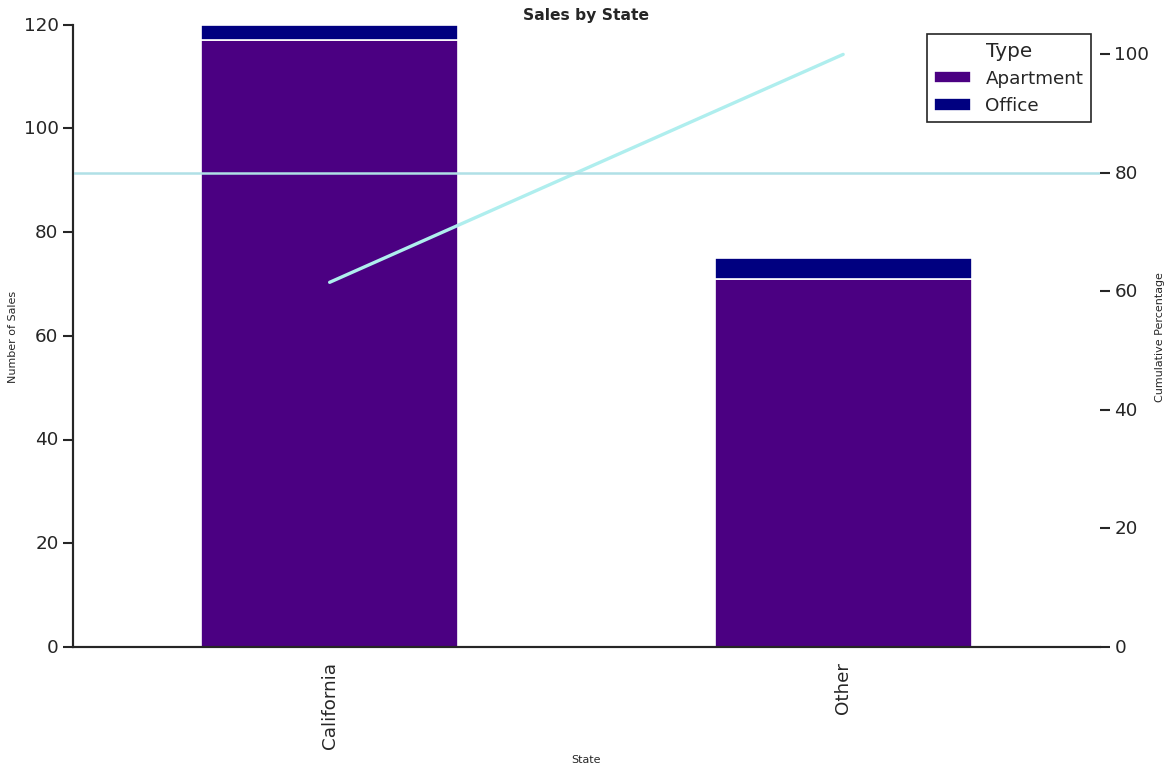

<Figure size 640x480 with 0 Axes>

In [19]:
fig, axis1 = plt.subplots(figsize=(15,10))
pivot_counts.plot(kind = 'bar', 
                  stacked = True, 
                  ax = axis1,
                  color=['indigo','navy'])
axis1.set_ylabel('Number of Sales', fontsize = 10)
axis1.set_xlabel('State', fontsize = 10)
axis1.tick_params(axis = 'x')
axis1.legend(title='Type', loc='upper right')

axis2 = axis1.twinx()
axis2.plot(range(len(cumulative_percent)),
           cumulative_percent.values,
           color = 'paleturquoise', linewidth = 3)
axis2.set_ylabel('Cumulative Percentage', fontsize = 10)
axis2.set_ylim(0,105)
axis2.tick_params(axis = 'y')
axis2.axhline(80, color ='powderblue')
plt.title('Sales by State', 
          fontsize = 14,
          fontweight = 'bold')
fig.tight_layout()
sns.despine()
plt.show()
plt.savefig('Sales by State.jpg')

In [20]:
dfmerged1 = pd.read_csv('dfmerged1.csv').copy()
dfmerged1.head()

,Unnamed: 0,customerid,full_name,age,entity,sex,country,state,purpose,deal_satisfaction,...,source,id,building,date_sale,type,property#,area,price,status,age_at_sale
0,0,C0001,Kamd Co,62.0,0.0,Unknown,1.0,1.0,0.0,5.0,...,Agency,1005,1,2004-03-01,1,5,410.71,117564.07,1,40.0
1,1,C0002,Jack Anderson,78.0,1.0,M,1.0,1.0,0.0,5.0,...,Website,1002,1,2004-03-01,1,2,1238.58,410932.67,1,56.0
2,2,C0003,Avah Huang,77.0,1.0,F,1.0,1.0,1.0,5.0,...,Website,1044,1,2004-06-01,0,44,827.87,229464.71,1,55.0
3,3,C0004,Nora Lynch,77.0,1.0,F,1.0,1.0,1.0,5.0,...,Website,1043,1,2004-06-01,0,43,1160.36,377313.56,1,55.0
4,4,C0005,Rodolfo Gibson,89.0,1.0,M,1.0,0.0,1.0,2.0,...,Website,1033,1,2004-08-01,0,33,1434.09,412856.56,1,67.0


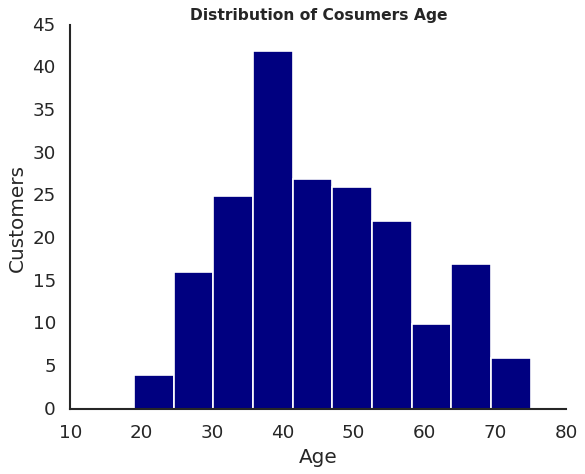

<Figure size 640x480 with 0 Axes>

In [21]:
sns.set_style('white')
plt.figure(figsize = (8, 6))
plt.hist(dfmerged1['age_at_sale'],
        bins = 10,
        color = 'navy')
plt.title('Distribution of Cosumers Age', fontsize = 14, weight = 'bold')
plt.xlabel('Age')
plt.ylabel('Customers')
sns.despine()
plt.show()
plt.savefig('Distribution of Cosumers Age.jpg')

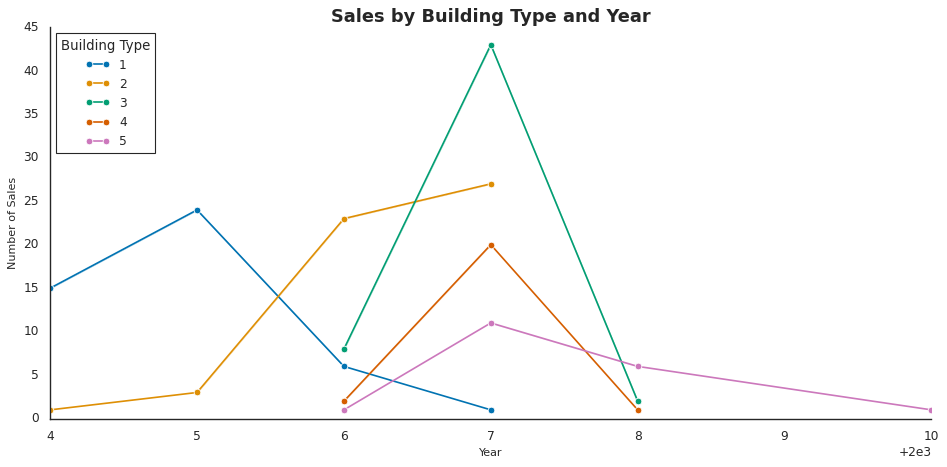

<Figure size 640x480 with 0 Axes>

In [48]:
sns.set_style('white')
sns.set_context('notebook')

plt.figure(figsize = (12, 6))
sns.lineplot(data = dfrsd,
             x = dfrsd ['year'],
             y = dfrsd['status'],
             hue='building',
             marker='o',
             estimator= 'sum',
             palette = 'colorblind')

plt.title('Sales by Building Type and Year', fontsize = 16, fontweight = 'bold')
plt.xlabel('Year', fontsize = 10)
plt.ylabel('Number of Sales', fontsize = 10)
plt.legend(title= 'Building Type',loc = 'upper left')

sns.despine()
plt.tight_layout()
plt.show()
plt.savefig('Sales by Building Type and Year')